In [ ]:
import json 
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.3

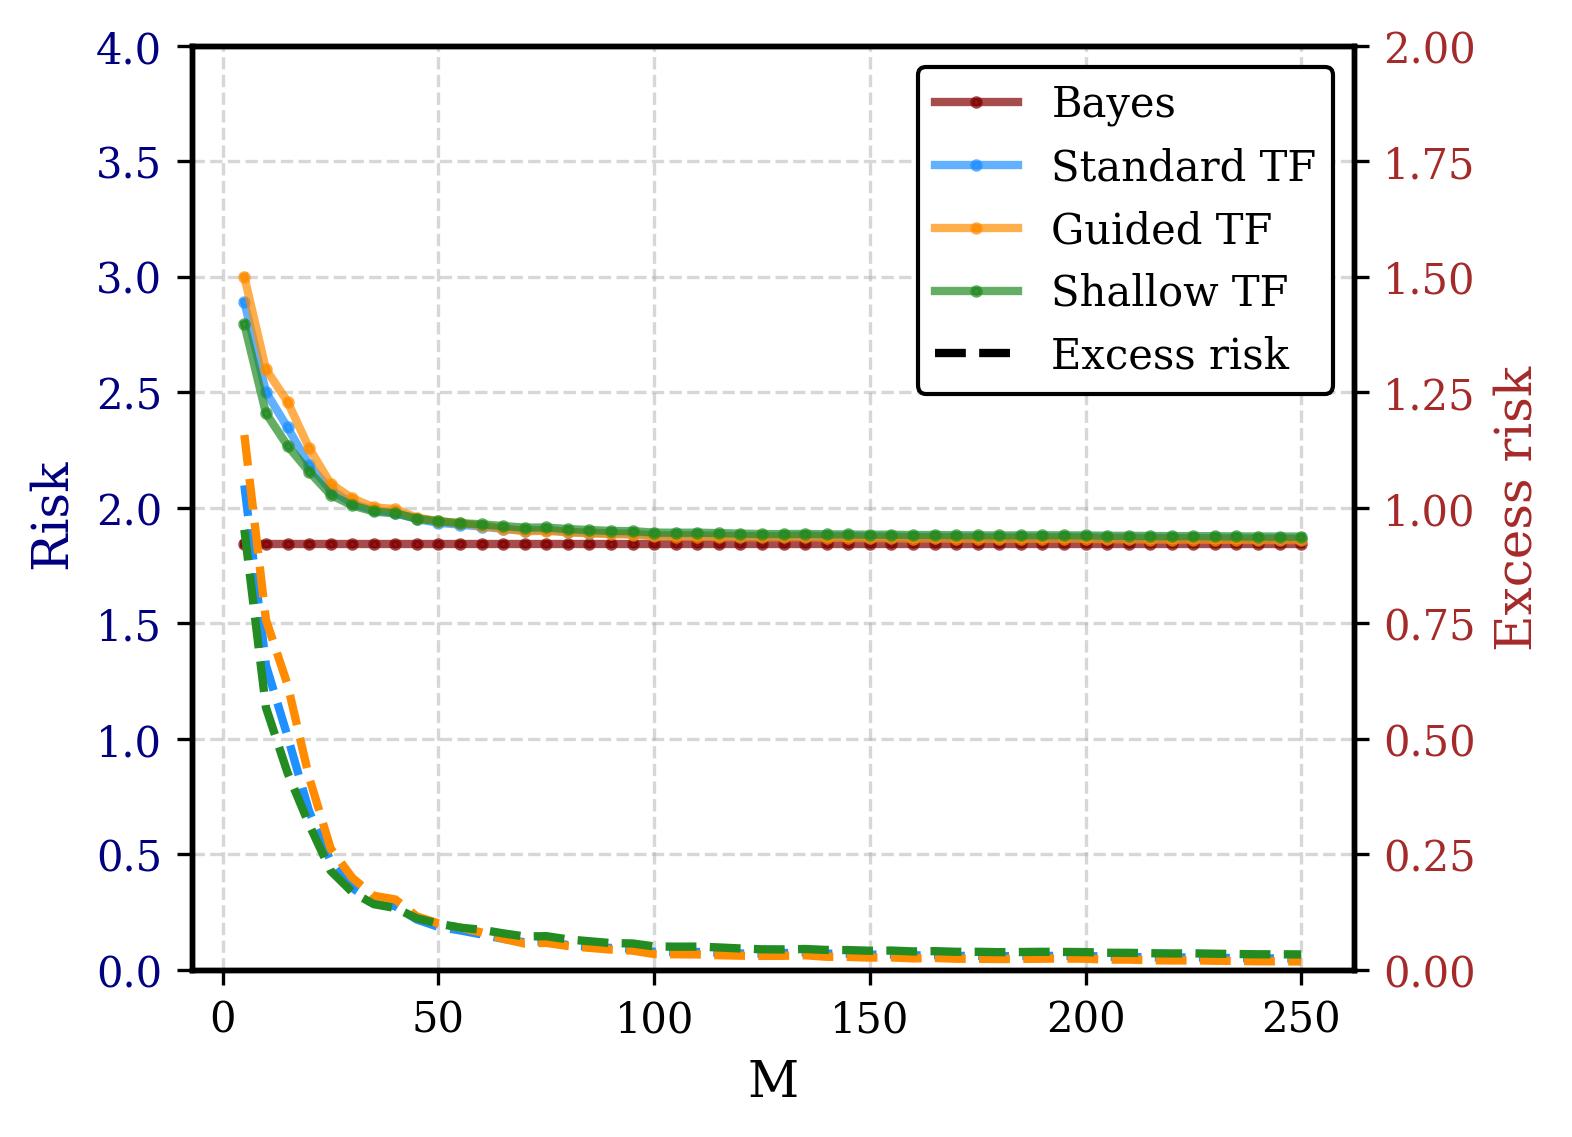

In [27]:

with open("./data/zsc-numsamples.json", "r") as f:
    data_dict = json.load(f)
fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
}

p_flip = np.array(data_dict["num_samples_list"])
run_types = list(colors.keys())
for model_type in run_types:
    if model_type == "Bayes":
        y_values = np.ones_like(p_flip)*data_dict[model_type][0]
    else:
        y_values = data_dict[model_type]
    ax1.plot(p_flip, y_values, label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("M", fontsize=12)
ax1.set_ylabel(r"Risk ", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 4)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# 右轴格式
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,2)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper right",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black")
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig2-ZSC-M.pdf", format="pdf", dpi=300, bbox_inches="tight")

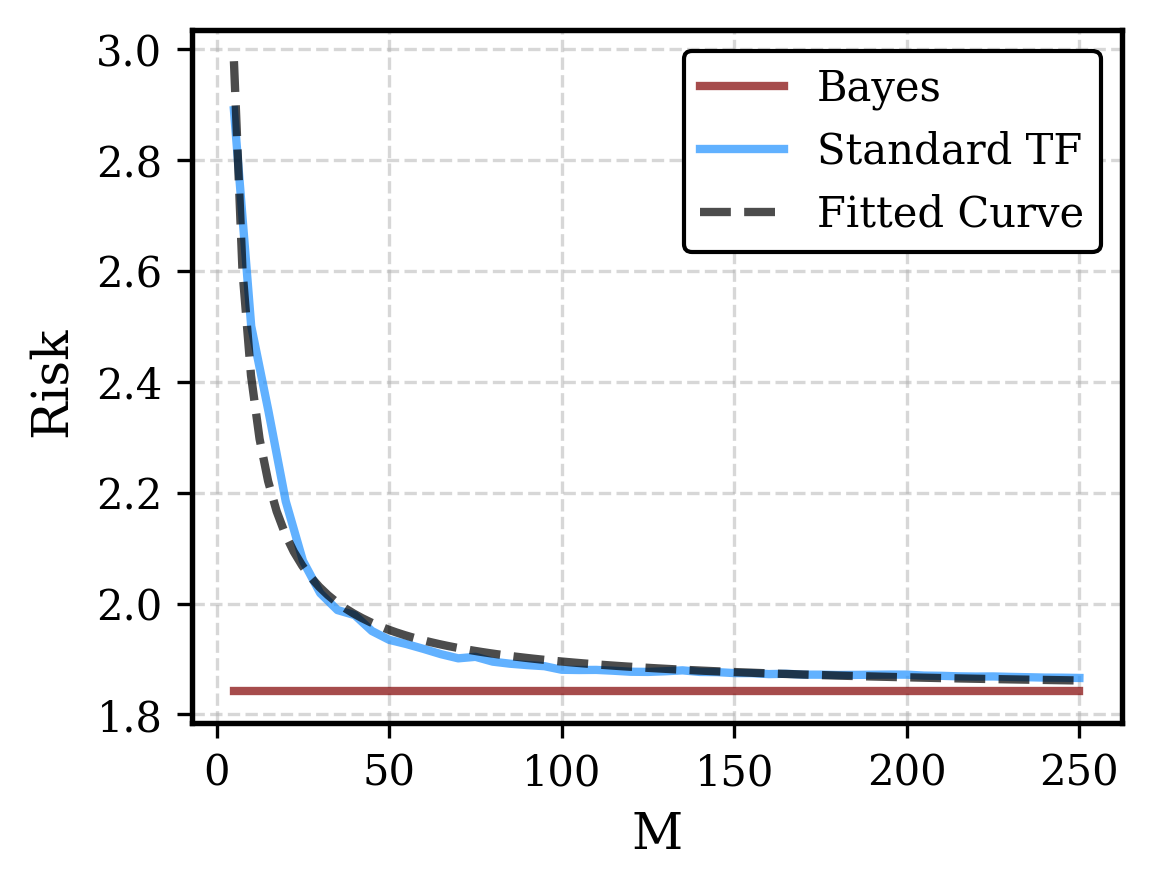

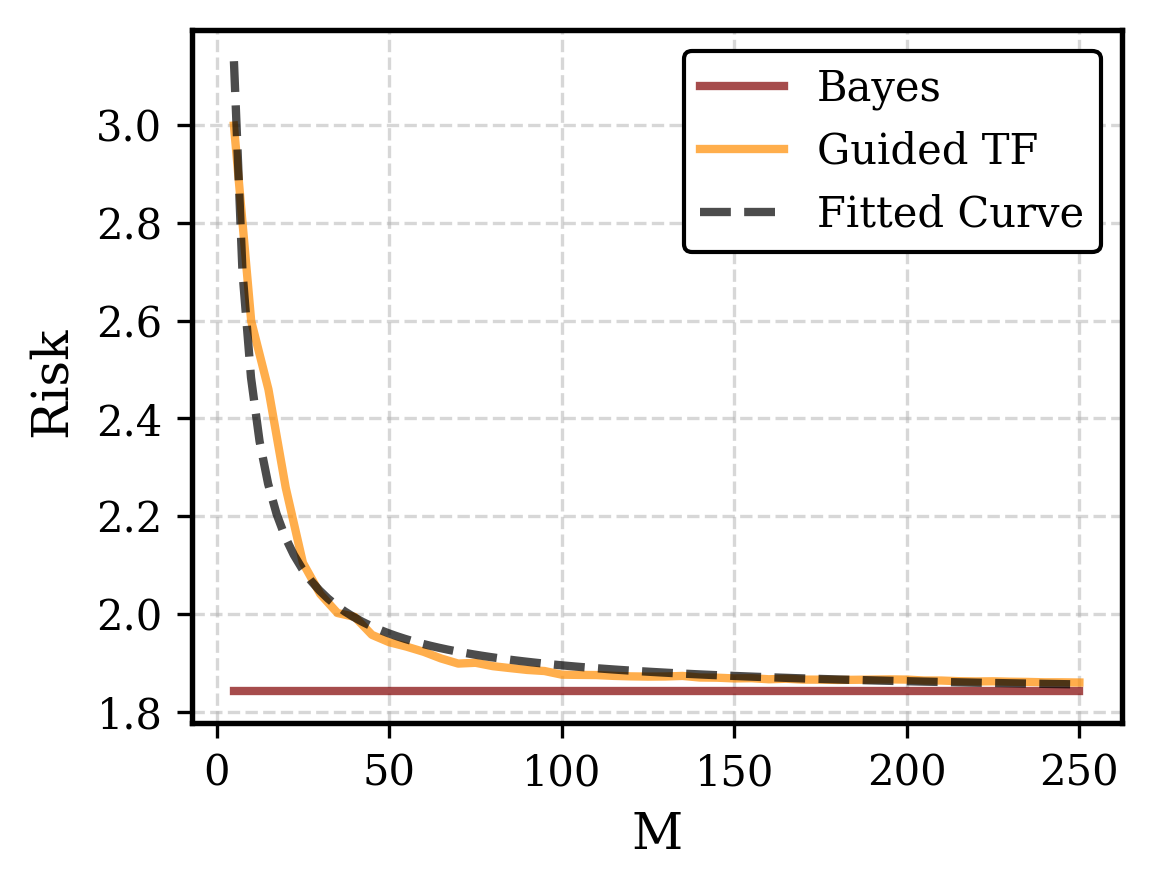

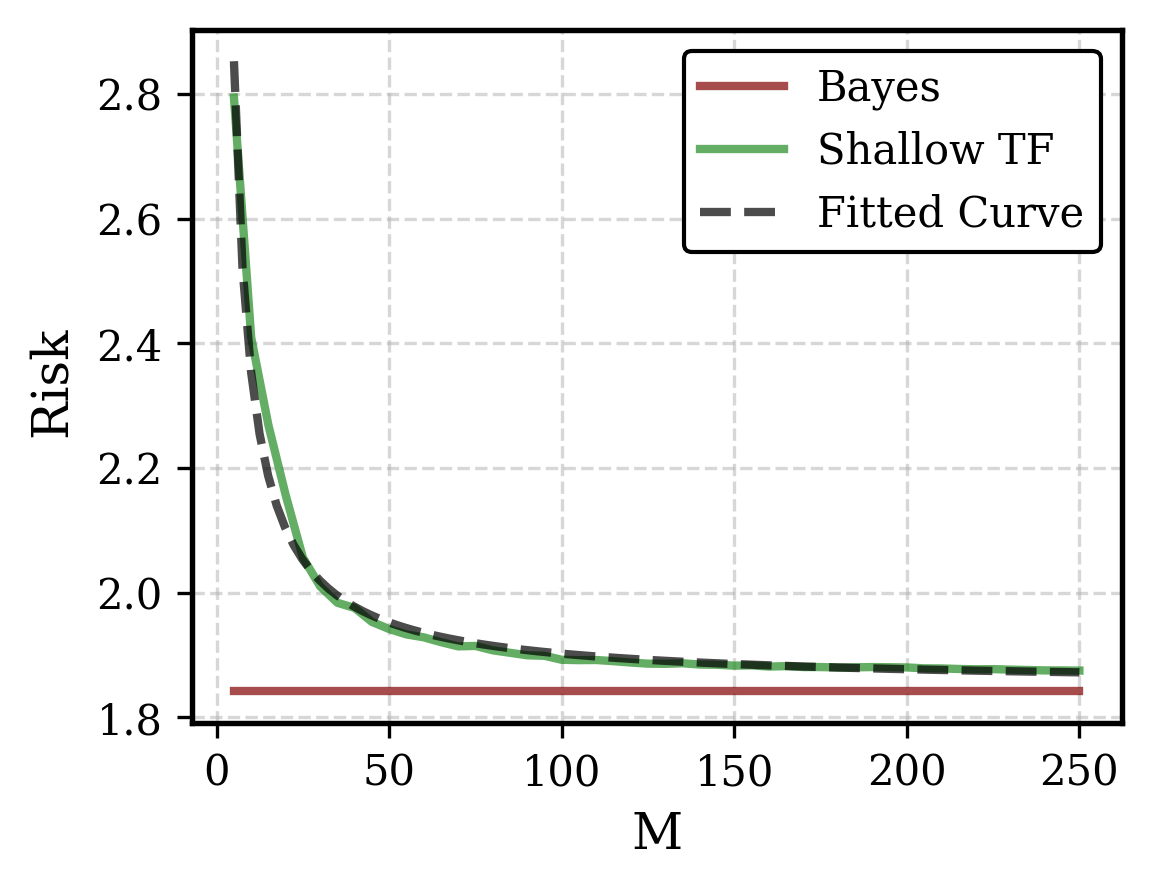

In [26]:
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.3
with open("./data/zsc-numsamples.json", "r") as f:
    data_dict = json.load(f)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
}

p_flip = np.array(data_dict["num_samples_list"])
run_types = list(colors.keys())
bayes_risk = data_dict["Bayes"]
bayes_risk = np.ones_like(p_flip)*bayes_risk[0]
for model_type in run_types[1:]:
    fig, ax1 = plt.subplots(figsize=(4, 3),dpi=300)
    y_values = data_dict[model_type]
    ax1.plot(p_flip, bayes_risk, label="Bayes", color="maroon", linewidth=2,  alpha=0.7)
    ax1.plot(p_flip, y_values, label=model_type, color=colors[model_type], linewidth=2, alpha=0.7)
    x_values = 1/p_flip 

    coeff  = np.polyfit(x_values, y_values, 1)
    A, B = coeff

    x_design = 1/np.linspace(5, 250, 100)
    y_design = A*x_design + B
    ax1.plot(1/x_design, y_design, label="Fitted Curve", color="black", linewidth=2, alpha=0.7, linestyle="--")
    ax1.set_xlabel("M", fontsize=12)
    ax1.set_ylabel(r"Risk ", fontsize=12)
    # ax1.tick_params(axis="y", labelcolor="navy")
    ax1.grid(True, ls="--", alpha=0.5)
    # ax1.set_ylim(0, 4)

    legend = ax1.legend( loc="upper right",
                        frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black")
    legend.get_frame().set_linewidth(1.0)
    plt.savefig(f"./output/Fig2-ZSC-Fit-{model_type}.pdf", format="pdf", dpi=300, bbox_inches="tight")